# Import Libraries

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Business Problem Understanding

The company invests money across different marketing channels such as TV, radio, social media, and digital advertising. The leadership team wants to understand which channels contribute most effectively to sales and how future marketing budgets should be allocated.

The objective of this project is to build a regression model that predicts sales based on marketing spend across different channels.

- Independent Variables:
  Marketing spend channels such as TV, radio, social media, and digital ads.

- Dependent Variable:
  Sales or revenue generated.

This is a regression problem because the target variable is continuous numerical data.

Linear regression helps businesses understand the relationship between marketing spend and sales, identify the most impactful channels, and make data-driven budget allocation decisions.

# Load Dataset

In [4]:
df = pd.read_csv("data/marketing_data.csv")

df.head()

,CampaignID,Month,Region,TV_Spend,Radio_Spend,SocialMedia_Spend,SearchAds_Spend,Influencer_Spend,Sales_Revenue
0,MKT0001,2023-01,East,70.02,14.67,31.74,35.44,6.99,408.48
1,MKT0002,2023-03,North,22.97,10.39,34.81,39.11,0.37,365.55
2,MKT0003,2023-04,Central,40.01,5.02,43.38,13.38,19.44,336.59
3,MKT0004,2023-05,North,40.84,37.61,15.26,30.91,13.76,409.73
4,MKT0005,2023-05,South,39.63,23.68,55.48,33.00,29.38,407.32


# Data Understanding and Cleaning

In [5]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Records:", df.duplicated().sum())

print("\nData Types:\n")
print(df.dtypes)

Dataset Shape: (420, 9)

Missing Values:

CampaignID           0
Month                0
Region               0
TV_Spend             0
Radio_Spend          0
SocialMedia_Spend    4
SearchAds_Spend      0
Influencer_Spend     0
Sales_Revenue        0
dtype: int64

Duplicate Records: 0

Data Types:

CampaignID            object
Month                 object
Region                object
TV_Spend             float64
Radio_Spend          float64
SocialMedia_Spend    float64
SearchAds_Spend      float64
Influencer_Spend     float64
Sales_Revenue        float64
dtype: object


In [6]:
df['SocialMedia_Spend'] = df['SocialMedia_Spend'].fillna(
    df['SocialMedia_Spend'].mean()
)

print(df.describe())

         TV_Spend  Radio_Spend  SocialMedia_Spend  SearchAds_Spend  \
count  420.000000   420.000000         420.000000       420.000000   
mean    42.539643    20.895881          31.131442        37.182333   
std     26.705188    10.793881          16.720809        19.125876   
min      5.060000     2.100000           1.370000         3.090000   
25%     22.850000    11.747500          16.137500        20.220000   
50%     40.510000    20.905000          31.545000        35.465000   
75%     60.230000    30.255000          46.352500        54.345000   
max    343.400000    39.960000          59.800000        69.720000   

       Influencer_Spend  Sales_Revenue  
count        420.000000     420.000000  
mean          16.071881     418.964476  
std           13.751809      80.960572  
min            0.050000     211.970000  
25%            7.675000     364.635000  
50%           15.765000     420.495000  
75%           22.957500     470.435000  
max          179.820000     645.540000  


# Outlier Analysis

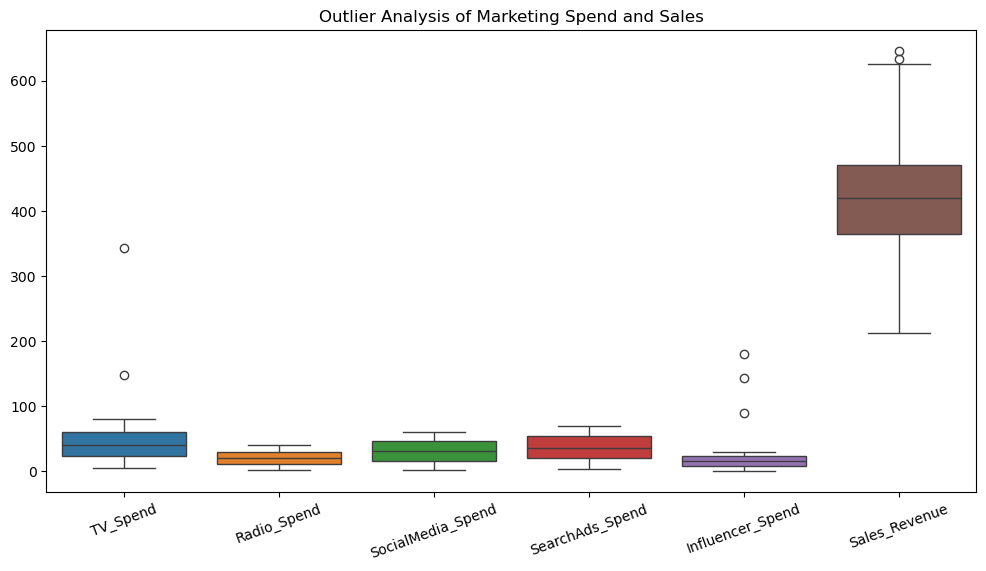

In [7]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df[['TV_Spend', 'Radio_Spend', 'SocialMedia_Spend',
                     'SearchAds_Spend', 'Influencer_Spend',
                     'Sales_Revenue']])

plt.title('Outlier Analysis of Marketing Spend and Sales')
plt.xticks(rotation=20)

plt.show()

### Interpretation
Most marketing channels show reasonable value distributions, although some outliers are visible in TV spend and influencer spend. These may represent high-budget campaigns and should be considered carefully during analysis.

# Exploratory Data Analysis

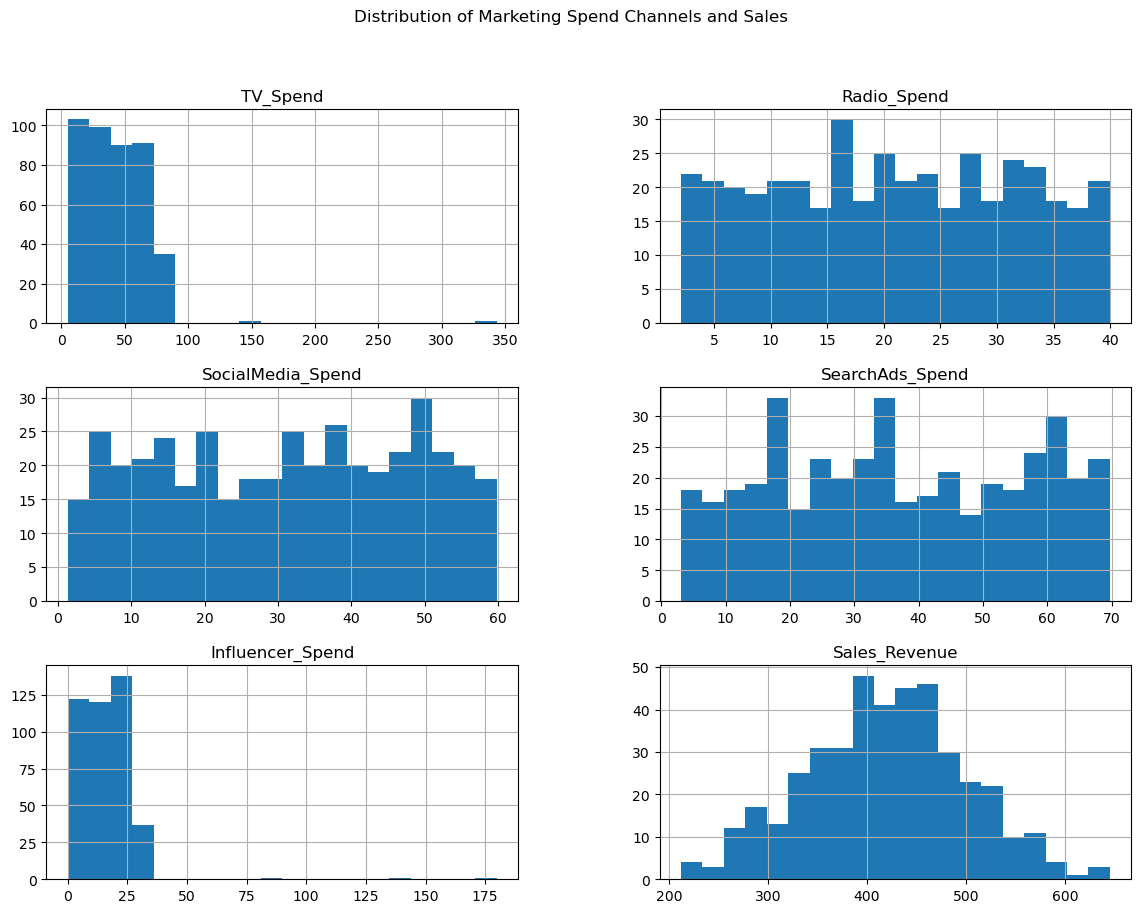

In [8]:
marketing_columns = [
    'TV_Spend',
    'Radio_Spend',
    'SocialMedia_Spend',
    'SearchAds_Spend',
    'Influencer_Spend',
    'Sales_Revenue'
]

df[marketing_columns].hist(figsize=(14,10), bins=20)

plt.suptitle('Distribution of Marketing Spend Channels and Sales')

plt.show()

### Interpretation
The distributions show how marketing budgets and sales revenue vary across campaigns. Most channels appear moderately distributed, while a few high-spend campaigns create slight skewness in the data.

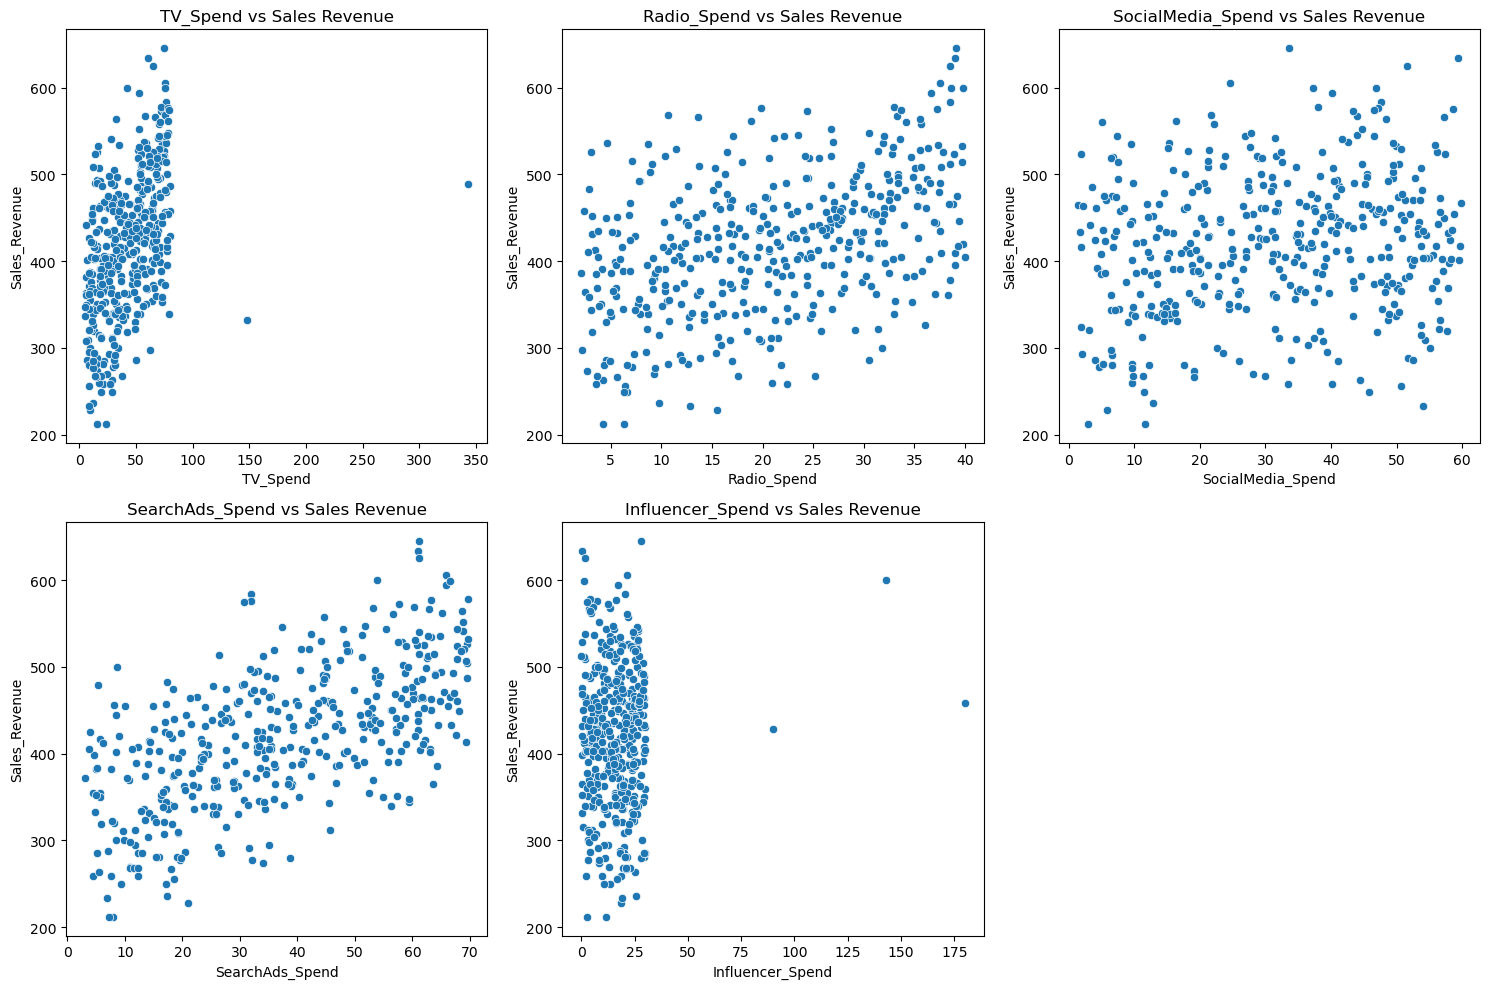

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15,10))

channels = [
    'TV_Spend',
    'Radio_Spend',
    'SocialMedia_Spend',
    'SearchAds_Spend',
    'Influencer_Spend'
]

for i, channel in enumerate(channels):
    sns.scatterplot(
        x=df[channel],
        y=df['Sales_Revenue'],
        ax=axes[i//3, i%3]
    )
    
    axes[i//3, i%3].set_title(f'{channel} vs Sales Revenue')

axes[1,2].axis('off')

plt.tight_layout()
plt.show()

### Interpretation
The scatter plots help visualize the relationship between marketing spend and sales revenue. Channels with clearer upward trends may have a stronger positive impact on sales performance.

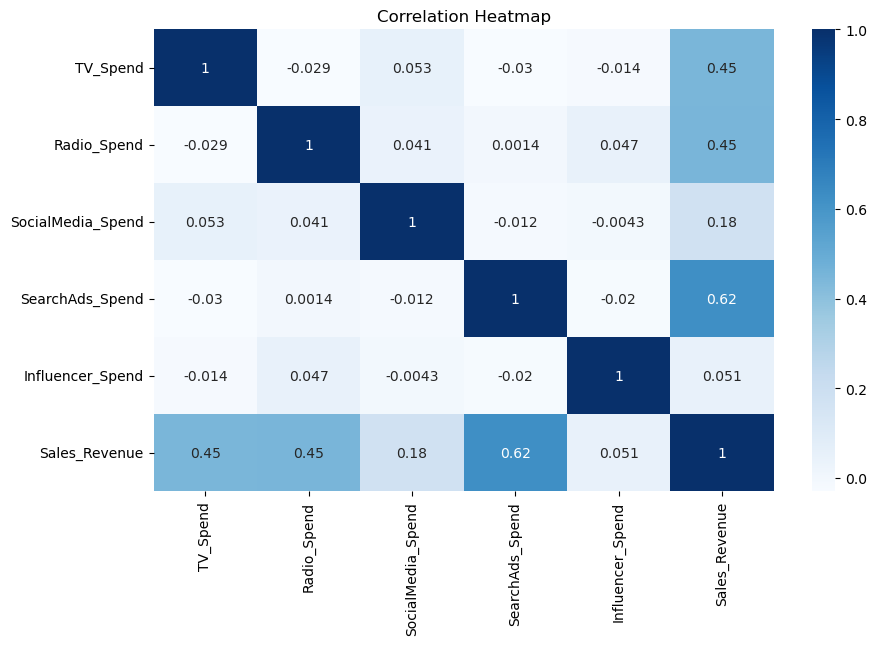

In [10]:
plt.figure(figsize=(10,6))

correlation = df[marketing_columns].corr()

sns.heatmap(correlation, annot=True, cmap='Blues')

plt.title('Correlation Heatmap')

plt.show()

### Interpretation
The heatmap shows the strength of relationships between marketing channels and sales revenue. Strong positive correlations suggest channels that may contribute more effectively to revenue generation.

# Model Building

In [11]:
X = df[[
    'TV_Spend',
    'Radio_Spend',
    'SocialMedia_Spend',
    'SearchAds_Spend',
    'Influencer_Spend'
]]

y = df['Sales_Revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model training completed.")

Model training completed.


In [12]:
coefficients = pd.DataFrame({
    'Channel': X.columns,
    'Coefficient': model.coef_
})

coefficients

,Channel,Coefficient
0,TV_Spend,1.445101
1,Radio_Spend,3.414541
2,SocialMedia_Spend,0.696221
3,SearchAds_Spend,2.674348
4,Influencer_Spend,0.202319


### Interpretation
Regression coefficients show how much sales revenue is expected to change when marketing spend increases by one unit, while keeping other channels constant.

Channels with higher positive coefficients appear to have stronger influence on sales performance.

# Model Evaluation

In [13]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 2))

MAE : 19.87
MSE : 913.16
RMSE: 30.22
R2 Score: 0.86


### Evaluation Interpretation

- The MAE indicates that the model predictions differ from actual sales revenue by approximately 19.87 units on average.
- The RMSE value shows the typical prediction error magnitude.
- The R² score of 0.86 indicates that the model explains approximately 86% of the variation in sales revenue.

Overall, the regression model performs well and captures a strong relationship between marketing spend and sales revenue.

# ROI and Channel Effectiveness Analysis

In [14]:
channel_effectiveness = coefficients.copy()

channel_effectiveness['Relative_Impact'] = (
    channel_effectiveness['Coefficient'] /
    channel_effectiveness['Coefficient'].sum()
) * 100

channel_effectiveness

,Channel,Coefficient,Relative_Impact
0,TV_Spend,1.445101,17.137214
1,Radio_Spend,3.414541,40.492488
2,SocialMedia_Spend,0.696221,8.256367
3,SearchAds_Spend,2.674348,31.714663
4,Influencer_Spend,0.202319,2.399267


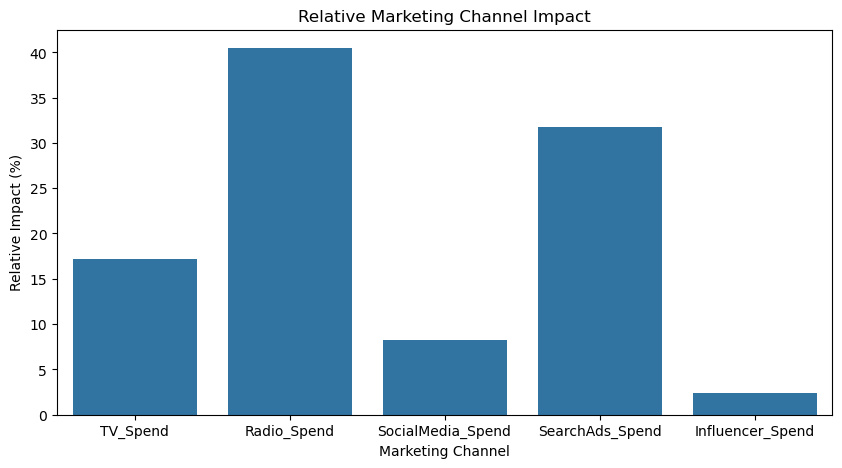

In [15]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=channel_effectiveness,
    x='Channel',
    y='Relative_Impact'
)

plt.title('Relative Marketing Channel Impact')
plt.xlabel('Marketing Channel')
plt.ylabel('Relative Impact (%)')

plt.show()

### Interpretation
Radio and Search Ads appear to contribute the strongest impact on sales revenue, while Influencer Spend shows comparatively lower effectiveness based on the regression model coefficients.

# Budget Recommendations

- Increase investment in Radio advertising because it shows the highest positive impact on sales revenue.
- Allocate additional budget to Search Ads since it demonstrates strong effectiveness and sales contribution.
- Maintain moderate investment in TV advertising as it shows a positive but lower impact compared to Radio and Search Ads.
- Reevaluate spending on Influencer marketing because it appears to have limited impact on sales performance.
- Improve Social Media campaign targeting and content strategy to increase effectiveness.
- Collect additional data such as customer demographics, campaign duration, conversion rates, and seasonality factors to improve future analysis.
- Before changing budgets significantly, the company should consider external market conditions, competition, and customer behavior trends.

# Conclusion

This project analyzed the relationship between marketing spend and sales revenue using multiple linear regression.

The analysis showed that Radio and Search Ads have the strongest positive impact on sales performance, while Influencer marketing contributes relatively less. The regression model achieved strong predictive performance with an R² score of 0.86.

These insights can help the company optimize marketing budget allocation, improve return on investment, and support data-driven marketing decisions.

In [16]:
coefficients.to_csv("outputs/channel_coefficients.csv", index=False)

channel_effectiveness.to_csv("outputs/channel_effectiveness.csv", index=False)